## Collateralized Debt Obligation and Structured Finance

### Miniproject 3 | Valuation For Financial Engineering

Team:
- Jiayi Chen
- Binny Singla

## The underlying assets

A bank has placed 10 speculative grade corporate bonds in a CDO it is looking to sell.  Each bond is 5 years in duration, makes quarterly coupon payments at an annual coupon rate of 6%, and the annual default probability is 4%.  The LGD is 60% for all bonds.  The market YTM on the bonds is 9%, and the risk-free interest rate is 1% per year.  The “correlation” between any two bonds’ default dates is equal to a constant of 0.20.  The bonds’ face values are $10 MM each.

## The CDO

The structuring group has proposed two PACs for the CDO.  The Class A tranche has an initial notional value of $20 MM and a coupon rate of 2% per year.  The Class B tranche has a notional value of $10 MM and a coupon rate of 4% per year.  The bank will retain the residuals as equity.

## The Waterfall

The waterfall is as follows:  Class A is paid first from available cash flows, and then Class B is paid.  The residual goes to the bank.  There are no carry-forwards, all cash flows are distributed as earned.  Suggestion:  Compute promised cash flows of the collateral, adjust the cash flows for default times, and distribute the cash flows according to the waterfall.

## Task 1.

Build a simulation model of the aggregate quarterly cash flows of the portfolio, as a function of the quarterly cash flows.  Be sure to correlate the simulated default dates.

## Task 2.

Apply the waterfall rules to determine the cash flow patterns to each class.

## Task 3.

Provide a statistical analysis of the cash flows (both the collateral and the classes) in a report suitable for a bank client.  Be sure to include probability distributions of the outcomes, and key sensitivities to the parameters.

## Assumptions

Each bond’s default time is modeled as an exponentially distributed random variable. If a bond defaults during a given quarter, the associated recovery payment is received in the immediately following quarter.


# Tools Setup

In [1]:
# Libraries
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path
from datetime import datetime

# Change working directory to the project root
if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)
    
PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT))

print("PROJECT ROOT:", PROJECT_ROOT)

PROJECT ROOT: /Users/binnysingla/Desktop/Credit-Default-Swap-Structured-Finance


## Task 1

- Step 1: Generate fixed random numbers (1000 cases for 10 bonds)

In [2]:
np.random.seed(42)                     
Z = np.random.normal(0, 1, size=(1000, 10))

raw_path = PROJECT_ROOT / "data" / "raw" / "fixed_normals.csv"
np.savetxt(raw_path, Z, delimiter=",")
print("Saved to:", raw_path)

Saved to: /Users/binnysingla/Desktop/Credit-Default-Swap-Structured-Finance/data/raw/fixed_normals.csv


- Step 2: Moment matching

A sample of 1,000 standard normal draws will not have a mean of exactly 0 and a standard deviation of exactly 1. Small deviations shift each bond's simulated default rate away from its true value. For example, a column mean of −0.06 raises the 5-year default probability from about 18.5% to about 20.2%. That would overstate expected losses purely because of sampling noise.

To remove this sampling error, each column (bond) is rescaled to have exactly zero mean and unit standard deviation:

$$\tilde{z}_{i,j} = \frac{z_{i,j} - \bar{z}_j}{s_j}$$

where $\bar{z}_j$ and $s_j$ are the sample mean and standard deviation of bond $j$'s 1,000 draws.

This adds no new information. It removes a sampling accident whose correct answer we already know. It also makes Part 2's parameter comparisons cleaner: the moment-matched draws are reused across all scenarios, so differences in results reflect parameter changes rather than noise.

In [3]:
Z_mm = (Z - Z.mean(axis=0)) / Z.std(axis=0)

In [4]:
print("Before adjustment - Mean:", Z.mean(axis=0).round(4))
print("Before adjustment - Standard Deviation:", Z.std(axis=0).round(4))
print("After adjustment - Mean:", Z_mm.mean(axis=0).round(4))   # Should all be 0
print("After adjustment - Standard Deviation:", Z_mm.std(axis=0).round(4))  # Should all be 1

Before adjustment - Mean: [ 0.0108  0.0313 -0.0225 -0.0431  0.0136 -0.0293 -0.0027  0.0055 -0.0231
  0.0381]
Before adjustment - Standard Deviation: [1.0049 1.0155 0.9829 0.9829 1.0121 1.0365 1.0307 1.0304 0.9864 0.9448]
After adjustment - Mean: [-0.  0.  0.  0. -0.  0. -0. -0. -0. -0.]
After adjustment - Standard Deviation: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


- Step 3: Sorting

Sort the 1000 cases from worst to best, so the case number itself means something: case 1 is the worst scenario, case 1000 the best.

In [5]:
row_sums = Z_mm.sum(axis=1)          # one sum per case (row)
order = np.argsort(row_sums)         # ascending: most negative first
Z_sorted = Z_mm[order]               # reorder whole rows

In [6]:
# Check that the sorting worked and that the column means and SDs are still correct
s = Z_sorted.sum(axis=1)
print("Worst 5 case sums:", s[:5].round(2))     # most negative
print("Best 5 case sums:",  s[-5:].round(2))    # most positive
print("Sorted correctly:", np.all(np.diff(s) >= 0))   # True
print("Column means still 0:", np.allclose(Z_sorted.mean(axis=0), 0))
print("Column SDs still 1:",   np.allclose(Z_sorted.std(axis=0), 1))

Worst 5 case sums: [-11.56 -10.    -9.1   -8.19  -8.06]
Best 5 case sums: [ 7.84  8.61  9.06  9.9  10.2 ]
Sorted correctly: True
Column means still 0: True
Column SDs still 1: True


In [7]:
# label the cases and bonds, and convert to a DataFrame for easier viewing
Z_df = pd.DataFrame(Z_sorted,
                    index=pd.RangeIndex(1, 1001, name="Case"),
                    columns=[f"Bond_{j}" for j in range(1, 11)])
Z_df.head()

,Bond_1,Bond_2,Bond_3,Bond_4,Bond_5,Bond_6,Bond_7,Bond_8,Bond_9,Bond_10
Case,,,,,,,,,,
1,-2.384148,-0.587424,-1.820628,-0.923392,-3.114332,-0.103943,-1.105304,0.052802,-1.624183,0.047424
2,-1.548093,-0.561867,0.416050,0.896151,-0.684543,-2.783395,0.510240,-1.189597,-2.021827,-3.038100
3,0.428761,-1.442608,-0.829063,-2.099688,-1.420339,0.200463,-1.903385,-1.442716,0.021022,-0.615691
4,-1.712946,-0.417890,-1.572375,-1.474581,-1.002764,-0.861488,-0.923562,0.497574,-0.489769,-0.230331
5,0.735333,-2.014887,0.363087,-0.251198,-0.841903,-0.688115,-0.205536,-3.500018,-0.687569,-0.967304


- Step 4: Correlated normals via Cholesky decomposition

To give every pair of bonds a correlation of $\rho = 0.20$, we follow the Cholesky method. The target correlation matrix $R$ is $10 \times 10$ with 1 on the diagonal and 0.20 elsewhere. Since each variable has unit variance, $R$ is also the covariance matrix $\Sigma$. Factor it as

$$R = LL^T$$

where $L$ is lower triangular. Then

$$Y = L \cdot Z, \quad Z = (Z_1, \dots, Z_{10}) \text{ iid } N(0,1)$$

produces correlated standard normals (the mean vector is $\mu = 0$). This works because $\text{Cov}(LZ) = L \cdot I \cdot L^T = LL^T = R$. The factorization exists because $R$ is positive definite.

We verify that $LL^T$ recovers $R$, and that the empirical correlation of the 1,000 simulated cases matches the 0.20 target within sampling noise.

In [8]:
# Target correlation matrix: 10 bonds, pairwise correlation 0.20
rho = 0.20
n_bonds = 10
R = np.full((n_bonds, n_bonds), rho)
np.fill_diagonal(R, 1.0)

In [9]:
# Cholesky factorization
L = np.linalg.cholesky(R)
print("L (first 5 rows/cols) =")
print(L[:5, :5].round(10))

L (first 5 rows/cols) =
[[1.         0.         0.         0.         0.        ]
 [0.2        0.9797959  0.         0.         0.        ]
 [0.2        0.16329932 0.96609178 0.         0.        ]
 [0.2        0.16329932 0.13801311 0.95618289 0.        ]
 [0.2        0.16329932 0.13801311 0.11952286 0.9486833 ]]


In [10]:
# Verify: L L^T should equal R
print("\nL L^T equals R:", np.allclose(L @ L.T, R))


L L^T equals R: True


In [11]:
# Generate correlated normals 
z = Z_sorted.T          # shape (10, 1000): rows = bonds, cols = cases
y = L @ z               # correlated normals, same shape
Y = y.T                 # back to (1000, 10): rows = cases, cols = bonds

In [12]:
# Display the matrices for the first 5 bonds and first 5 cases
print("z = Z_sorted.T (first 5 bonds × first 5 cases):")
print(z[:5, :5].round(3))

print("\ny = L @ z (first 5 bonds × first 5 cases):")
print(y[:5, :5].round(3))

print("\nY = y.T (first 5 cases × first 5 bonds):")
print(Y[:5, :5].round(3))

z = Z_sorted.T (first 5 bonds × first 5 cases):
[[-2.384 -1.548  0.429 -1.713  0.735]
 [-0.587 -0.562 -1.443 -0.418 -2.015]
 [-1.821  0.416 -0.829 -1.572  0.363]
 [-0.923  0.896 -2.1   -1.475 -0.251]
 [-3.114 -0.685 -1.42  -1.003 -0.842]]

y = L @ z (first 5 bonds × first 5 cases):
[[-2.384e+00 -1.548e+00  4.290e-01 -1.713e+00  7.350e-01]
 [-1.052e+00 -8.600e-01 -1.328e+00 -7.520e-01 -1.827e+00]
 [-2.332e+00  1.000e-03 -9.510e-01 -1.930e+00  1.690e-01]
 [-1.707e+00  5.130e-01 -2.272e+00 -2.038e+00 -3.720e-01]
 [-3.889e+00 -8.860e-01 -1.863e+00 -1.755e+00 -9.610e-01]]

Y = y.T (first 5 cases × first 5 bonds):
[[-2.384e+00 -1.052e+00 -2.332e+00 -1.707e+00 -3.889e+00]
 [-1.548e+00 -8.600e-01  1.000e-03  5.130e-01 -8.860e-01]
 [ 4.290e-01 -1.328e+00 -9.510e-01 -2.272e+00 -1.863e+00]
 [-1.713e+00 -7.520e-01 -1.930e+00 -2.038e+00 -1.755e+00]
 [ 7.350e-01 -1.827e+00  1.690e-01 -3.720e-01 -9.610e-01]]


In [13]:
# Verify empirical correlation matches the target
corr = np.corrcoef(y)   
off_diag = corr[~np.eye(n_bonds, dtype=bool)]
print("\nEmpirical correlation (first 5 bonds):")
print(corr[:5, :5].round(3))
print(f"Average pairwise correlation: {off_diag.mean():.4f} (target {rho})")


Empirical correlation (first 5 bonds):
[[1.    0.215 0.23  0.231 0.194]
 [0.215 1.    0.208 0.194 0.209]
 [0.23  0.208 1.    0.195 0.214]
 [0.231 0.194 0.195 1.    0.18 ]
 [0.194 0.209 0.214 0.18  1.   ]]
Average pairwise correlation: 0.1978 (target 0.2)


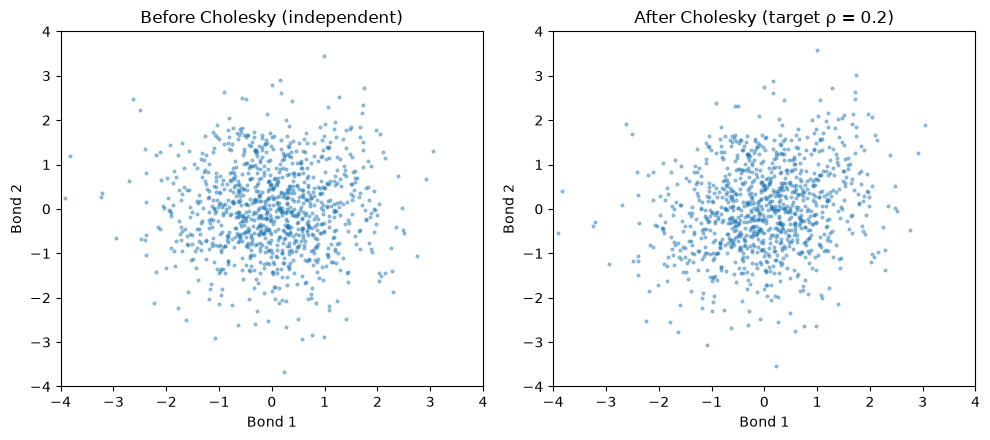

In [14]:
# Visualize the results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].scatter(Z_sorted[:, 0], Z_sorted[:, 1], s=4, alpha=0.4)
axes[0].set_title("Before Cholesky (independent)")
axes[1].scatter(Y[:, 0], Y[:, 1], s=4, alpha=0.4)
axes[1].set_title(f"After Cholesky (target ρ = {rho})")
for ax in axes:
    ax.set_xlabel("Bond 1"); ax.set_ylabel("Bond 2")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
plt.tight_layout()
plt.show()

- Step 5: Correlated default times (Gaussian copula, exponential marginals)

The correlated normals are converted to default times in two steps:

1. Map to correlated uniforms with the standard normal CDF: $U_{i,j} = \Phi(Y_{i,j})$.
2. Apply the exponential inverse CDF: $\tau_{i,j} = -\ln(1 - U_{i,j})/\lambda$.

The hazard rate is set so that the annual default probability is exactly 4%: $\lambda = -\ln(1 - 0.04) \approx 0.0408$. We use $1 - U$ (rather than $U$) so that a low normal draw maps to an early default, consistent with the worst-to-best ordering in Step 3.

Default times are converted to quarters ($\tau \times 4$). A bond defaults in quarter $\lceil 4\tau \rceil$ if $4\tau \le 20$, and survives to maturity otherwise. Each bond's marginal default probability is unchanged by the correlation; what changes is that defaults cluster in the same cases, which fattens the tail of the number-of-defaults distribution.

In [15]:
# Calculate default times from correlated normals
from scipy.stats import norm

# Parameters
PD = 0.04                          # annual default probability
lam = -np.log(1 - PD)              # hazard rate ≈ 0.0408i
T_quarters = 20                    # 5 years × 4 quarters

# 1. Normal -> uniform
U = norm.cdf(Y)                    # shape (1000, 10)

# 2. Uniform -> default time (years); low Y -> early default
tau_years = -np.log(1-U) / lam

# 3. Default quarter: 1..20 = quarter of default, 0 = survives
tau_q = tau_years * 4
default_q = np.where(tau_q <= T_quarters, np.ceil(tau_q), 0).astype(int)

In [16]:
# Print first 5 cases × 5 bonds
print(f"lambda = {lam:.4f}")
print("\nU (first 5 cases × 5 bonds):")
print(U[:5, :5].round(3))
print("\nDefault time in quarters:")
print(tau_q[:5, :5].round(2))
print("\nDefault quarter (0 = survives):")
print(default_q[:5, :5])

lambda = 0.0408

U (first 5 cases × 5 bonds):
[[0.009 0.146 0.01  0.044 0.   ]
 [0.061 0.195 0.5   0.696 0.188]
 [0.666 0.092 0.171 0.012 0.031]
 [0.043 0.226 0.027 0.021 0.04 ]
 [0.769 0.034 0.567 0.355 0.168]]

Default time in quarters:
[[  0.84  15.5    0.97   4.4    0.  ]
 [  6.15  21.24  67.96 116.68  20.37]
 [107.44   9.47  18.36   1.14   3.11]
 [  4.34  25.1    2.66   2.06   3.96]
 [143.55   3.37  82.02  42.96  18.07]]

Default quarter (0 = survives):
[[ 1 16  1  5  1]
 [ 7  0  0  0  0]
 [ 0 10 19  2  4]
 [ 5  0  3  3  4]
 [ 0  4  0  0 19]]


In [17]:
# Cross-check: 5-year default probability
defaulted = default_q > 0                   # True = defaults within 5 years
n_defaults = defaulted.sum(axis=1)          # number of defaults per case
pi5 = 1 - (1 - PD)**5                       # 5-year default probability ≈ 0.1846

print(defaulted.shape)
print(n_defaults.shape)

# 1. Marginal default rates
print(f"1-yr default rate: {(tau_years <= 1).mean():.4f} (target {PD})")
print(f"5-yr default rate: {defaulted.mean():.4f} (target {pi5:.4f})")
print(f"Avg defaults per case: {n_defaults.mean():.3f} (target {10*pi5:.3f})")

# 2. Clustering: correlated vs independent
from scipy.stats import binom
p5_sim = (n_defaults >= 5).mean()
p5_ind = 1 - binom.cdf(4, 10, pi5)
print(f"\nP(5+ defaults): simulated {p5_sim:.4f} vs independent {p5_ind:.4f}")

# 3. Distribution of number of defaults
print("\nNumber of defaults per case:")
print(pd.Series(n_defaults).value_counts().sort_index())

# 4. Sorting check: worst vs best cases
print("\nDefaults in worst 10 cases:", n_defaults[:10])
print("Defaults in best 10 cases: ", n_defaults[-10:])

(1000, 10)
(1000,)
1-yr default rate: 0.0410 (target 0.04)
5-yr default rate: 0.1827 (target 0.1846)
Avg defaults per case: 1.827 (target 1.846)

P(5+ defaults): simulated 0.0840 vs independent 0.0237

Number of defaults per case:
0     245
1     270
2     207
3     119
4      75
5      45
6      21
7      12
8       4
9       1
10      1
Name: count, dtype: int64

Defaults in worst 10 cases: [10  5  8  8  6  8  6  5  9  7]
Defaults in best 10 cases:  [0 0 0 0 0 1 0 0 0 0]


We notice: 
- **Right-skewed with a long tail:** most cases are mild (72% have 0–2 defaults), but 8.4% have 5+ defaults, and the worst case has all 10 bonds defaulting.
- **The mean understates the risk:** an average of 1.83 defaults hides the tail scenarios that drive tranche losses.

- Step 6: Bond cash flows

Each bond's promised schedule is a quarterly coupon of $10\text{MM} \times 6\%/4 = 0.15\text{MM}$, plus the 10MM face value at Q20. Following the defaultable bond model in §5.4, a default in quarter $d$ truncates this schedule:

| Situation | Cash flow ($MM) |
|---|---|
| Quarters before $d$ | 0.15 coupon |
| Default quarter $d$ | Recovery $(1 - 60\%) \times 10 = 4$, no coupon |
| After $d$ | 0 |
| No default | 0.15 each quarter, plus 10 at Q20 |

The result is a 1,000 × 10 × 20 array (cases × bonds × quarters). `show_case(n)` displays the 10 × 20 cash-flow table for any case $n$ from 1 to 1,000.

In [18]:
# Bond parameters (all amounts in $MM)
face = 10.0                       # face value of each bond
coupon_rate = 0.06                # annual coupon rate
LGD = 0.60                        # loss given default

coupon = face * coupon_rate / 4   # quarterly coupon = 0.15
recovery = face * (1 - LGD)       # recovery at default = 4.0

n_cases = 1000
n_bonds = 10
n_quarters = 20

In [19]:
from src.cdo_funs import bond_cash_flows, all_bond_cash_flows, portfolio_cash_flows

In [20]:
# Theoretical promised cash flows for the first 5 bonds (no defaults)
bond_names = [f"Bond_{j}" for j in range(1, 6)]
quarter_names = [f"Q{q}" for q in range(1, 21)]

promised = pd.DataFrame(
    [bond_cash_flows(0) for _ in range(5)],   # 0 = no default
    index=bond_names, columns=quarter_names
)

print(" Theoretical Promised cash flows, first 5 bonds ($MM):")
display(promised.round(2))

 Theoretical Promised cash flows, first 5 bonds ($MM):


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20
Bond_1,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,10.15
Bond_2,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,10.15
Bond_3,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,10.15
Bond_4,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,10.15
Bond_5,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,10.15


In [21]:
# Calculate actual cash flows for all bonds and all cases
bond_cf = all_bond_cash_flows(default_q)      # default_q comes from Step 5
print("bond_cf shape:", bond_cf.shape)        # (1000, 10, 20)

bond_cf shape: (1000, 10, 20)


In [22]:
# See Actual Cash Flows for a specific case
case = 1   # pick any case from 1 to 1000

actual = pd.DataFrame(
    bond_cf[case - 1, :5],
    index=bond_names, columns=quarter_names
)
actual.insert(0, "Default Q", default_q[case - 1, :5])   # 0 = no default

print(f"Actual cash flows in case {case}, first 5 bonds ($MM):")
display(actual.round(2))

Actual cash flows in case 1, first 5 bonds ($MM):


,Default Q,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,...,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20
Bond_1,1,0.15,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
Bond_2,16,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,...,0.15,0.15,0.15,0.15,0.15,0.15,4.0,0.0,0.0,0.0
Bond_3,1,0.15,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
Bond_4,5,0.15,0.15,0.15,0.15,0.15,4.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
Bond_5,1,0.15,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0


- Step 7: Portfolio cash flows

Summing the 10 bonds' cash flows gives the portfolio's quarterly cash flows: a 1,000 × 20 table (cases × quarters). This is the final output of Task 1 and the input to the waterfall in Task 2.

**Check against the analytic expectation** With survival probability $S(t) = e^{-\lambda t}$, the expected cash flow of one bond in quarter $q$ is

$$E[CF_q] = 0.15 \cdot S\!\left(\tfrac{q}{4}\right) + 4 \cdot \left[S\!\left(\tfrac{q-1}{4}\right) - S\!\left(\tfrac{q}{4}\right)\right] \;\big(+\,10 \cdot S(5) \text{ at } q = 20\big)$$

that is, the coupon if the bond survives the quarter, plus recovery if it defaults during the quarter. The portfolio expectation is 10 times this. The simulated mean across the 1,000 cases should match it closely, and both lie below the promised schedule (1.5MM per quarter, 101.5MM at Q20) because of expected default losses.

In [23]:
# Portfolio Quarterly Cash Flows: sum across all bonds for each case
port_cf = portfolio_cash_flows(bond_cf)       # shape (1000, 20): cases × quarters

port_df = pd.DataFrame(port_cf,
                       index=pd.RangeIndex(1, 1001, name="Case"),
                       columns=[f"Q{q}" for q in range(1, 21)])

print("Portfolio cash flows, first 5 cases ($MM):")
display(port_df.head().round(2))

Portfolio cash flows, first 5 cases ($MM):


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20
Case,,,,,,,,,,,,,,,,,,,,
1,1.5,16.90,4.75,0.75,0.75,4.60,0.6,0.60,4.45,4.30,4.15,0.15,0.15,0.15,0.15,0.15,4.00,0.00,0.00,0.00
2,1.5,13.05,1.05,1.05,1.05,1.05,4.9,4.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,50.75
3,1.5,5.35,9.05,1.05,4.90,0.90,0.9,4.75,0.75,0.75,4.60,0.60,0.60,0.60,0.60,0.60,0.60,0.60,0.60,24.45
4,1.5,1.50,1.50,9.20,8.90,8.60,0.6,4.45,0.45,0.45,0.45,4.30,0.30,0.30,0.30,0.30,0.30,0.30,0.30,20.30
5,1.5,5.35,1.35,1.35,5.20,1.20,1.2,5.05,1.05,1.05,1.05,1.05,4.90,0.90,0.90,0.90,0.90,0.90,0.90,44.75


In [24]:
# Cross-check: expected cash flows vs simulated mean
lam = hazard_rate if False else -np.log(1 - 0.04)
q = np.arange(1, 21)
S_curr = np.exp(-lam * q / 4)              # survival to end of quarter
S_prev = np.r_[1.0, S_curr[:-1]]          # survival to start of quarter

coupon_cf = 0.15* S_prev
default_prob = S_prev - S_curr
recover_cf = 4.0 * np.r_[0.0, default_prob[:-1]]  # recovery paid in next quarter after default

exp_bond = coupon_cf + recover_cf

exp_bond[-1] += 10.0 * S_curr[-1]  # add face value at maturity if survives

exp_port = 10 * exp_bond  # 10 bonds

check = pd.DataFrame({
    "Promised": [1.5] * 19 + [101.5],
    "Expected (analytic)": exp_port.round(3),
    "Simulated mean": port_cf.mean(axis=0)
}, index=[f"Q{q}" for q in range(1, 21)]).round(3)

display(check)

,Promised,Expected (analytic),Simulated mean
Q1,1.5,1.500,1.500
Q2,1.5,1.891,1.904
Q3,1.5,1.872,1.823
Q4,1.5,1.853,1.918
Q5,1.5,1.834,1.842
Q6,1.5,1.815,1.858
Q7,1.5,1.797,1.722
Q8,1.5,1.779,1.784
Q9,1.5,1.761,1.777
Q10,1.5,1.743,1.685


In [25]:
# Standard error of the mean (SE) and difference in terms of SE
se = port_cf.std(axis=0, ddof=1) / np.sqrt(port_cf.shape[0])
check["SE"] = se.round(3)
check["Diff / SE"] = ((check["Simulated mean"] - check["Expected (analytic)"]) / se).round(2)
display(check)
print("All within 3 SE:", (check["Diff / SE"].abs() < 3).all())

,Promised,Expected (analytic),Simulated mean,SE,Diff / SE
Q1,1.5,1.500,1.500,0.000,NaN
Q2,1.5,1.891,1.904,0.045,0.29
Q3,1.5,1.872,1.823,0.036,-1.35
Q4,1.5,1.853,1.918,0.043,1.51
Q5,1.5,1.834,1.842,0.039,0.20
Q6,1.5,1.815,1.858,0.042,1.02
Q7,1.5,1.797,1.722,0.034,-2.23
Q8,1.5,1.779,1.784,0.038,0.13
Q9,1.5,1.761,1.777,0.039,0.41
Q10,1.5,1.743,1.685,0.035,-1.68


All within 3 SE: False


The analytical expected cash flows are derived assuming an exponential default time with constant intensity 
λ. The probability of default in each quarter is obtained from the exponential PDF, while survival probabilities determine whether coupon and principal payments are received.

The simulated means are very close to the analytical values across all quarters. Most standardized differences (Diff / SE) are within ±2; the isolated value of −2.23 in Q7 is consistent with normal Monte Carlo variation. Q1 has SE = 0 because the first coupon payment is deterministic, so Diff / SE is undefined. The lower expected cash flow in Q20 reflects the possibility of default before maturity, which reduces the expected principal repayment.

# Task 2

Assuming the CDO pays quarterly coupons and on last quarter pay coupon + notional values: 

The Class A tranche has an initial notional value of $20 MM and a coupon rate of 2% per year.  
The Class B tranche has a notional value of $10 MM and a coupon rate of 4% per year.  
The bank will retain the residuals as equity.


- Step 1: Expected Cash Flows for Class A and Class B

In [26]:
# Bond parameters (all amounts in $MM)
faceA = 20.0                       # face value of each bond
faceB = 10.0                       # face value of each bond
coupon_rateA = 0.02                # annual coupon rate
coupon_rateB = 0.04                # annual coupon rate

couponA = faceA * coupon_rateA / 4   # quarterly coupon = 0.15
couponB = faceB * coupon_rateB / 4   # quarterly coupon = 0.15

n_cases = 1000
n_bondsA = 1
n_bondsB = 1 
n_quarters = 20

In [27]:
from src.cdo_funs import bond_cash_flows_Class

In [28]:
# Theoretical promised cash flows for the Class A CDO
bond_name = [f"ClassA_{j}" for j in range(1)]
quarter_names = [f"Q{q}" for q in range(1, 21)]
cashflow_classA = bond_cash_flows_Class(20,0.02).T 

promised = pd.DataFrame(
    [cashflow_classA],   
    index=bond_name, columns=quarter_names
)

print(f" Theoretical Promised cash flows for {bond_name} ($MM):")
display(promised.round(2))

# Theoretical promised cash flows for the Class B CDO
bond_name = [f"ClassB_{j}" for j in range(1)]
quarter_names = [f"Q{q}" for q in range(1, 21)]
cashflow_classB = bond_cash_flows_Class(10,0.04).T

promised = pd.DataFrame(
    [cashflow_classB],   
    index=bond_name, columns=quarter_names
)

print(f" Theoretical Promised cash flows for {bond_name} ($MM):")
display(promised.round(2))

 Theoretical Promised cash flows for ['ClassA_0'] ($MM):


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20
ClassA_0,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,20.1


 Theoretical Promised cash flows for ['ClassB_0'] ($MM):


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20
ClassB_0,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,10.1


- Step 2: Since we got the theoretical promise cash flows for both class A and class B, now we check whether the portfolio cash flow in every simulated case (1000 cases in total) are sufficient to pay the CDO (from Class A to Class B, finally to the equity tranche) 

In [29]:
# Transfer the Theoretical Promised cash flows for Class A and Class B to a 1000(cases)*20(payments) matrix for calculation
cashflow_classA = np.tile(cashflow_classA, (1000, 1))  # shape (1000, 20)
cashdlow_classB = np.tile(cashflow_classB, (1000, 1))  # shape (1000, 20)

In [30]:
# We first see can the portfolio cash flows cover class A cash flows
Residuals_AfterA = port_cf - cashflow_classA
print(f"Residuals after Class A cash flows ($MM):")
display(Residuals_AfterA.round(2))

# Actual Tranches Payments for Class A
Actual_ClassA_Payments = np.minimum(cashflow_classA,Residuals_AfterA)
Actual_ClassA_Payments = np.maximum(Actual_ClassA_Payments, 0)
print(f"Actual Class A Payments ($MM):")
display(Actual_ClassA_Payments.round(2))

Residuals after Class A cash flows ($MM):


array([[  1.4 ,  16.8 ,   4.65, ...,  -0.1 ,  -0.1 , -20.1 ],
       [  1.4 ,  12.95,   0.95, ...,   0.65,   0.65,  30.65],
       [  1.4 ,   5.25,   8.95, ...,   0.5 ,   0.5 ,   4.35],
       ...,
       [  1.4 ,   1.4 ,   1.4 , ...,   1.4 ,   1.4 ,  81.4 ],
       [  1.4 ,   1.4 ,   1.4 , ...,   1.4 ,   1.4 ,  81.4 ],
       [  1.4 ,   1.4 ,   1.4 , ...,   1.4 ,   1.4 ,  81.4 ]],
      shape=(1000, 20))

Actual Class A Payments ($MM):


array([[ 0.1 ,  0.1 ,  0.1 , ...,  0.  ,  0.  ,  0.  ],
       [ 0.1 ,  0.1 ,  0.1 , ...,  0.1 ,  0.1 , 20.1 ],
       [ 0.1 ,  0.1 ,  0.1 , ...,  0.1 ,  0.1 ,  4.35],
       ...,
       [ 0.1 ,  0.1 ,  0.1 , ...,  0.1 ,  0.1 , 20.1 ],
       [ 0.1 ,  0.1 ,  0.1 , ...,  0.1 ,  0.1 , 20.1 ],
       [ 0.1 ,  0.1 ,  0.1 , ...,  0.1 ,  0.1 , 20.1 ]], shape=(1000, 20))

In [31]:
# We then see can the residual equity after Class A cash flow payments cover class B cash flows
Residuals_AfterB = Residuals_AfterA - cashflow_classB
print(f"Residuals after ClassB cash flows ($MM):")
display(Residuals_AfterB.round(2))

# Actual Tranches Payments for Class B
Actual_ClassB_Payments = np.minimum(cashflow_classB,Residuals_AfterB)
Actual_ClassB_Payments = np.maximum(Actual_ClassB_Payments, 0)
print(f"Actual Class B Payments ($MM):")
display(Actual_ClassB_Payments.round(2))

Residuals after ClassB cash flows ($MM):


array([[  1.3 ,  16.7 ,   4.55, ...,  -0.2 ,  -0.2 , -30.2 ],
       [  1.3 ,  12.85,   0.85, ...,   0.55,   0.55,  20.55],
       [  1.3 ,   5.15,   8.85, ...,   0.4 ,   0.4 ,  -5.75],
       ...,
       [  1.3 ,   1.3 ,   1.3 , ...,   1.3 ,   1.3 ,  71.3 ],
       [  1.3 ,   1.3 ,   1.3 , ...,   1.3 ,   1.3 ,  71.3 ],
       [  1.3 ,   1.3 ,   1.3 , ...,   1.3 ,   1.3 ,  71.3 ]],
      shape=(1000, 20))

Actual Class B Payments ($MM):


array([[ 0.1,  0.1,  0.1, ...,  0. ,  0. ,  0. ],
       [ 0.1,  0.1,  0.1, ...,  0.1,  0.1, 10.1],
       [ 0.1,  0.1,  0.1, ...,  0.1,  0.1,  0. ],
       ...,
       [ 0.1,  0.1,  0.1, ...,  0.1,  0.1, 10.1],
       [ 0.1,  0.1,  0.1, ...,  0.1,  0.1, 10.1],
       [ 0.1,  0.1,  0.1, ...,  0.1,  0.1, 10.1]], shape=(1000, 20))

In [32]:
# Finally, we see what is left for the equity tranches after Class A and Class B cash flow payments
Residuals_For_EquityTranches = Residuals_AfterB
print(f"Residuals for Equity Tranches ($MM):")
display(Residuals_For_EquityTranches.round(2))

# Actual Payments for Equity Tranches
Actual_Equity_Payments = np.maximum(Residuals_AfterB,0)
print(f"Actual Cash Flows for Equity Tranches($MM):")
display(Actual_Equity_Payments.round(2))

Residuals for Equity Tranches ($MM):


array([[  1.3 ,  16.7 ,   4.55, ...,  -0.2 ,  -0.2 , -30.2 ],
       [  1.3 ,  12.85,   0.85, ...,   0.55,   0.55,  20.55],
       [  1.3 ,   5.15,   8.85, ...,   0.4 ,   0.4 ,  -5.75],
       ...,
       [  1.3 ,   1.3 ,   1.3 , ...,   1.3 ,   1.3 ,  71.3 ],
       [  1.3 ,   1.3 ,   1.3 , ...,   1.3 ,   1.3 ,  71.3 ],
       [  1.3 ,   1.3 ,   1.3 , ...,   1.3 ,   1.3 ,  71.3 ]],
      shape=(1000, 20))

Actual Cash Flows for Equity Tranches($MM):


array([[ 1.3 , 16.7 ,  4.55, ...,  0.  ,  0.  ,  0.  ],
       [ 1.3 , 12.85,  0.85, ...,  0.55,  0.55, 20.55],
       [ 1.3 ,  5.15,  8.85, ...,  0.4 ,  0.4 ,  0.  ],
       ...,
       [ 1.3 ,  1.3 ,  1.3 , ...,  1.3 ,  1.3 , 71.3 ],
       [ 1.3 ,  1.3 ,  1.3 , ...,  1.3 ,  1.3 , 71.3 ],
       [ 1.3 ,  1.3 ,  1.3 , ...,  1.3 ,  1.3 , 71.3 ]], shape=(1000, 20))

Another Possible Waterfall Tranche Check

In [33]:
# 1. Class A: paid first, from all available collateral cash
Actual_ClassA_Payments = np.minimum(port_cf, cashflow_classA)
cash_after_A = port_cf - Actual_ClassA_Payments
print(f"Actual_ClassA_Payments($MM):")
display(Actual_ClassA_Payments.round(2))

Actual_ClassA_Payments($MM):


array([[ 0.1,  0.1,  0.1, ...,  0. ,  0. ,  0. ],
       [ 0.1,  0.1,  0.1, ...,  0.1,  0.1, 20.1],
       [ 0.1,  0.1,  0.1, ...,  0.1,  0.1, 20.1],
       ...,
       [ 0.1,  0.1,  0.1, ...,  0.1,  0.1, 20.1],
       [ 0.1,  0.1,  0.1, ...,  0.1,  0.1, 20.1],
       [ 0.1,  0.1,  0.1, ...,  0.1,  0.1, 20.1]], shape=(1000, 20))

In [34]:
# 2. Class B: paid from what is left after Class A
Actual_ClassB_Payments = np.minimum(cash_after_A, cashflow_classB)
cash_after_B = cash_after_A - Actual_ClassB_Payments
print(f"Actual_ClassB_Payments($MM):")
display(Actual_ClassB_Payments.round(2))

Actual_ClassB_Payments($MM):


array([[ 0.1 ,  0.1 ,  0.1 , ...,  0.  ,  0.  ,  0.  ],
       [ 0.1 ,  0.1 ,  0.1 , ...,  0.1 ,  0.1 , 10.1 ],
       [ 0.1 ,  0.1 ,  0.1 , ...,  0.1 ,  0.1 ,  4.35],
       ...,
       [ 0.1 ,  0.1 ,  0.1 , ...,  0.1 ,  0.1 , 10.1 ],
       [ 0.1 ,  0.1 ,  0.1 , ...,  0.1 ,  0.1 , 10.1 ],
       [ 0.1 ,  0.1 ,  0.1 , ...,  0.1 ,  0.1 , 10.1 ]], shape=(1000, 20))

In [35]:
# 3. Equity: receives everything that remains
Actual_Equity_Payments = cash_after_B
print(f"Actual_Equity_Payments($MM):")
display(Actual_Equity_Payments.round(2))

Actual_Equity_Payments($MM):


array([[ 1.3 , 16.7 ,  4.55, ...,  0.  ,  0.  ,  0.  ],
       [ 1.3 , 12.85,  0.85, ...,  0.55,  0.55, 20.55],
       [ 1.3 ,  5.15,  8.85, ...,  0.4 ,  0.4 ,  0.  ],
       ...,
       [ 1.3 ,  1.3 ,  1.3 , ...,  1.3 ,  1.3 , 71.3 ],
       [ 1.3 ,  1.3 ,  1.3 , ...,  1.3 ,  1.3 , 71.3 ],
       [ 1.3 ,  1.3 ,  1.3 , ...,  1.3 ,  1.3 , 71.3 ]], shape=(1000, 20))

# Task 3

- Provide a statistical analysis of the cash flows (both the collateral and the classes) in a report suitable for a bank client.  Be sure to include probability distributions of the outcomes, and key sensitivities to the parameters.

Step 1: Collateral analysis

- Number of defaults: the histogram and the correlated vs. independent comparison
- Total cash flow over 5 years: histogram of the sum of the 20 quarters per case, compared with the promised 130MM.Report the mean, SD, and the 5th/1st percentiles.
- Cash flow over time: a "fan chart" by quarter showing the mean with 5th–95th percentile bands. It shows that the risk is concentrated at Q20, when principal is due.

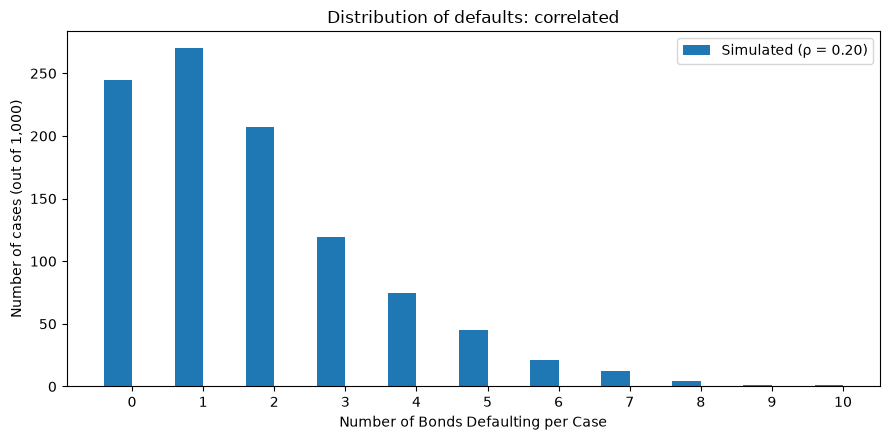


Number of Bonds Defaulting per ase:
0     245
1     270
2     207
3     119
4      75
5      45
6      21
7      12
8       4
9       1
10      1
Name: count, dtype: int64


In [36]:
# Number of Defaults in Simulated Cases
from scipy.stats import binom

k = np.arange(0, 11)                                   # 0..10 bonds that can default
pi5 = 1 - 0.96**5                                      # 5-yr default prob ≈ 0.1846

sim_counts = pd.Series(n_defaults).value_counts().reindex(k, fill_value=0)

width = 0.4
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(k - width/2, sim_counts.values, width, label="Simulated (ρ = 0.20)")
ax.set_xticks(k)
ax.set_xlabel("Number of Bonds Defaulting per Case")
ax.set_ylabel("Number of cases (out of 1,000)")
ax.set_title("Distribution of defaults: correlated")
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "Output" / "defaults_distribution.png", dpi=200)
plt.show()

# Distribution of number of defaults
print("\nNumber of Bonds Defaulting per ase:")
print(pd.Series(n_defaults).value_counts().sort_index())

Conclusion
- We noticed that in 72.2% cases, the portfolio has 0-2 defaulting bonds. 
- In worst case scenarios (9-10 defualting bonds), only 1 case respectively.

Promised total:   130.0
Mode Payment:       130.0
Mean Payment:       115.97
Expected loss:    14.03
SD:               13.43
5th percentile:   90.39
1st percentile:   74.70
kurtosis: 1.68
Skewness: -1.24


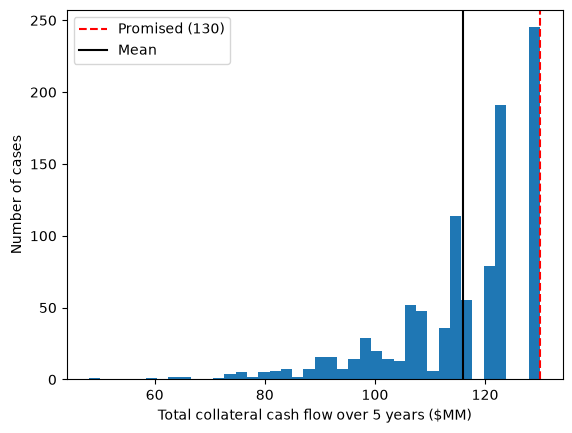

In [37]:
# Total cash flow over 5 years
total_cf = port_cf.sum(axis=1)          # one total per case, shape (1000,)
promised_total = 19 * 1.5 + 101.5       # 130

print(f"Promised total:   {promised_total:.1f}")
print(f"Mode Payment:       {pd.Series(total_cf).round(4).mode().iloc[0]:.1f}")
print(f"Mean Payment:       {total_cf.mean():.2f}")
print(f"Expected loss:    {promised_total - total_cf.mean():.2f}")
print(f"SD:               {total_cf.std():.2f}")
print(f"5th percentile:   {np.percentile(total_cf, 5):.2f}")
print(f"1st percentile:   {np.percentile(total_cf, 1):.2f}")
print(f"kurtosis: {pd.Series(total_cf).kurtosis():.2f}")
print(f"Skewness: {pd.Series(total_cf).skew():.2f}")

plt.hist(total_cf, bins=40)
plt.axvline(promised_total, color="red", linestyle="--", label="Promised (130)")
plt.axvline(total_cf.mean(), color="black", label="Mean")
plt.xlabel("Total collateral cash flow over 5 years ($MM)")
plt.ylabel("Number of cases")
plt.legend()
plt.show()

In conclusion:
- The Mode is $130 MM, which is full payment without defaults. While the Mean is $115.97 MM, meaning that majority of cases don't have serious defaults.
- The Kurtosis is 1.68, meaning our distribution have heavier tails than normal distribution. 
- The Skewness is -1.24, meaning our distribution has strong asymmetry and is left-skewed(More cases towards full payment than defaults).

Step 2: Tranche/CDO Analysis

In [38]:
promised = {"Class A": 22.0, "Class B": 12.0} 
totals = {"Class A": Actual_ClassA_Payments.sum(axis=1),
          "Class B": Actual_ClassB_Payments.sum(axis=1),
          "Equity":  Actual_Equity_Payments.sum(axis=1)}

rows = {}
for name, tot in totals.items():
    p = promised.get(name)
    short = (p - tot) if p is not None else None
    rows[name] = {
        "Promised total": p if p is not None else "—",
        "Expected received": tot.mean(),
        "P(any shortfall)": (short > 1e-9).mean() if p is not None else "—",
        # 1e-9 is a small tolerance to avoid floating point issues
        "Expected shortfall": short.mean() if p is not None else "—",
        "5th pct received": np.percentile(tot, 5),
        "1st pct received": np.percentile(tot, 1),
    }
display(pd.DataFrame(rows).round(3))

,Class A,Class B,Equity
Promised total,22.000,12.000,—
Expected received,21.970,11.944,82.05635
P(any shortfall),0.002,0.006,—
Expected shortfall,0.030,0.056,—
5th pct received,22.000,12.000,56.385
1st pct received,22.000,12.000,41.85


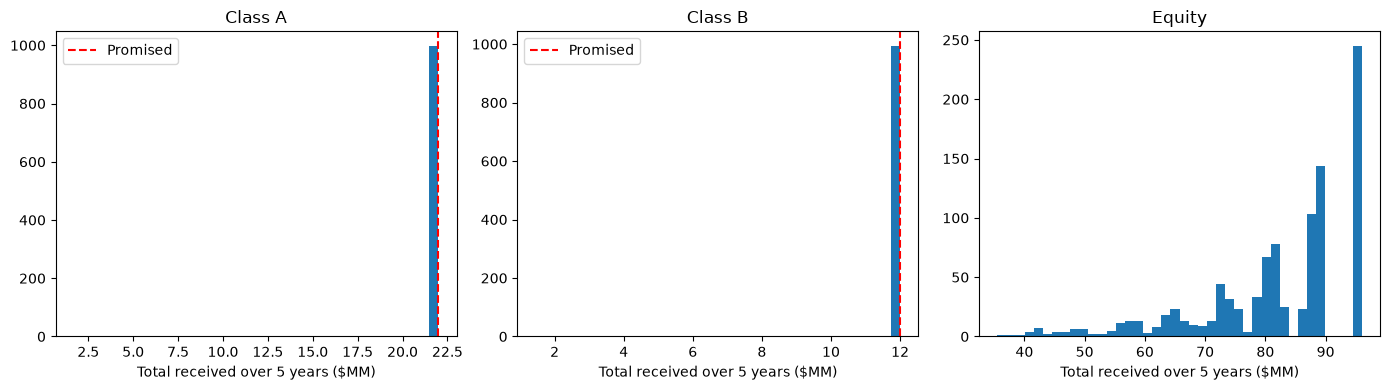

In [39]:
# Histograms
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, tot) in zip(axes, totals.items()):
    ax.hist(tot, bins=40)
    if name in promised:
        ax.axvline(promised[name], color="red", linestyle="--", label="Promised")
        ax.legend()
    ax.set_title(name)
    ax.set_xlabel("Total received over 5 years ($MM)")
plt.tight_layout()
plt.show()

## Step 2 Needs to be fixed

Step 3: Sensitivity analysis

We rerun the full model (Task 1 + Task 2) while changing one parameter at a time, keeping the others at the base case (ρ = 0.20, PD = 4%, LGD = 60%). Every run reuses the same fixed random numbers (`Z_sorted`), so differences between runs come only from the parameter change, not from sampling noise.

- **Correlation ρ:** drives how much defaults cluster (the tail).
- **Annual PD:** drives how often bonds default.
- **LGD:** drives how much is lost per default.
- **Combined stress:** in a recession, PD and correlation rise together.

In [40]:
from src.sensitivity_funs import BASE, GRID, KEY_METRICS, run_model, summarize, \
    run_sensitivity, run_all_sensitivities, run_stress, plot_sensitivity

base = summarize(run_model(Z_sorted, **BASE))
display(pd.Series(base, name="Base case").round(4).to_frame())

,Base case
Avg defaults,1.8270
P(5+ defaults),0.0840
Collateral mean,115.9700
Collateral 1st pct,74.7000
P(A shortfall),0.0020
A expected shortfall,0.0302
P(B shortfall),0.0060
B expected shortfall,0.0561
Equity mean,82.0564
Equity 5th pct,56.3850


**Base case results (ρ = 0.20, PD = 4%, LGD = 60%)**

- **Collateral:** expected total cash flow is 115.97MM against 130MM promised, an expected loss of about 14MM (11%). In the worst 1% of cases, the pool returns only about 75MM.

- **Class A and B are very safe:** Class A receives less than its promised 22MM in only 2 of 1,000 cases (0.2%), and Class B less than its 12MM in 6 cases (0.6%). Averaged over all cases, the shortfalls are tiny (0.03MM and 0.06MM), but in the cases where they occur, Class A loses about 15MM and Class B about 9MM on average.

- **Equity absorbs almost all the risk:** it receives 82.06MM on average (96MM with no defaults) and about 56MM in the worst 5% of cases. Roughly 99% of the collateral's expected loss falls on the equity.


Sensitivity to correlation ρ


,Avg defaults,P(5+ defaults),Collateral mean,Collateral 1st pct,P(A shortfall),A expected shortfall,P(B shortfall),B expected shortfall,Equity mean,Equity 5th pct
rho,,,,,,,,,,
0.0,1.841,0.019,115.9098,90.8475,0.000,0.0000,0.000,0.0000,81.9098,64.8000
0.1,1.830,0.049,115.9918,84.2370,0.000,0.0000,0.000,0.0000,81.9918,61.4950
0.2,1.827,0.084,115.9700,74.7000,0.002,0.0302,0.006,0.0561,82.0564,56.3850
0.3,1.817,0.104,116.0745,66.8435,0.005,0.0874,0.014,0.1250,82.2868,49.2000
0.5,1.822,0.141,116.0607,52.5745,0.021,0.3180,0.042,0.3972,82.7760,44.3925


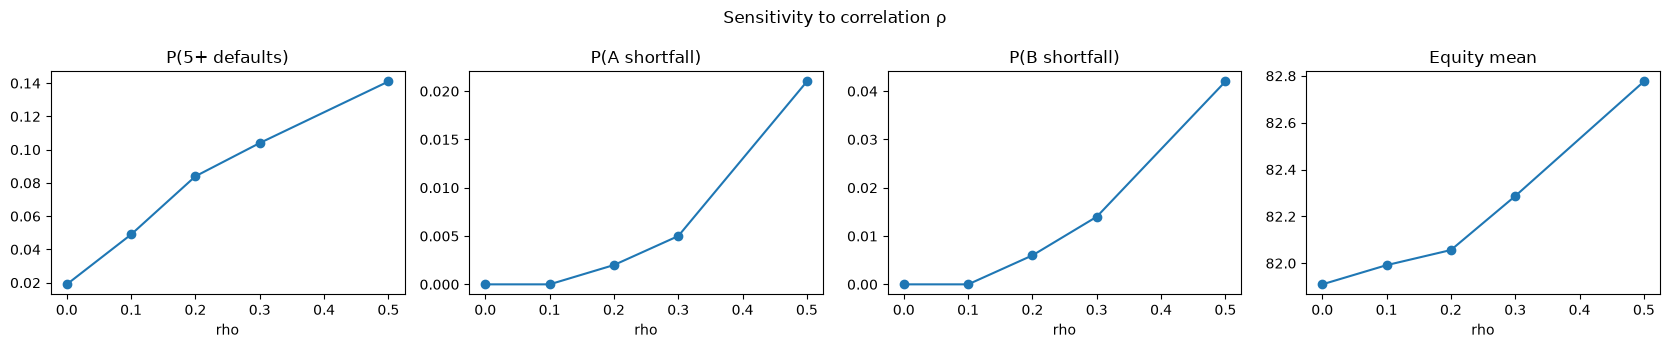


Sensitivity to annual PD


,Avg defaults,P(5+ defaults),Collateral mean,Collateral 1st pct,P(A shortfall),A expected shortfall,P(B shortfall),B expected shortfall,Equity mean,Equity 5th pct
pd_annual,,,,,,,,,,
0.02,0.958,0.011,122.6316,92.1925,0.001,0.0098,0.001,0.0101,88.6516,69.715
0.04,1.827,0.084,115.9700,74.7000,0.002,0.0302,0.006,0.0561,82.0564,56.385
0.06,2.648,0.184,109.7316,65.7910,0.006,0.0915,0.018,0.1687,75.9918,47.700
0.08,3.403,0.291,103.8464,57.9970,0.013,0.1725,0.046,0.4160,70.4349,41.490


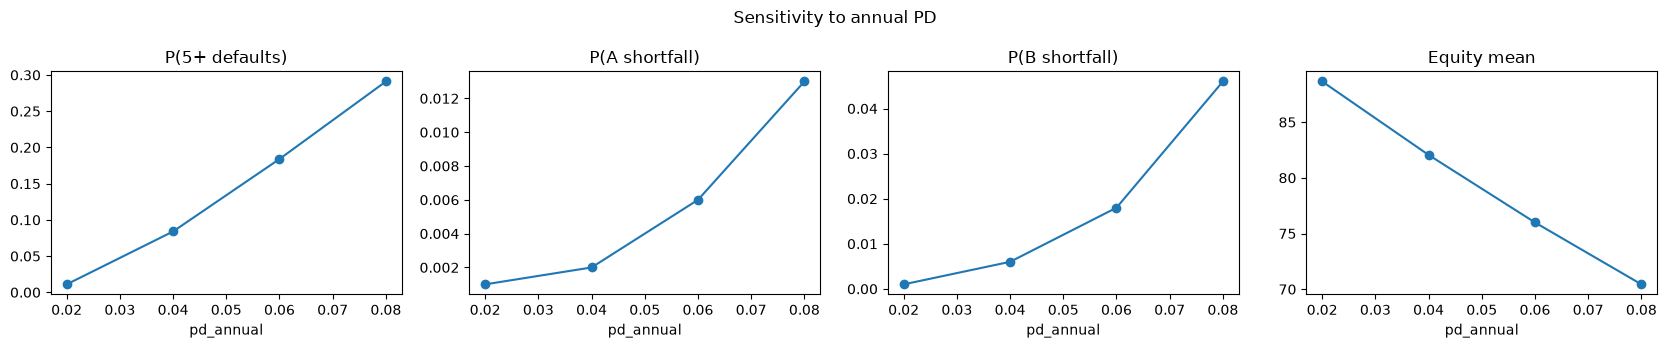


Sensitivity to LGD


,Avg defaults,P(5+ defaults),Collateral mean,Collateral 1st pct,P(A shortfall),A expected shortfall,P(B shortfall),B expected shortfall,Equity mean,Equity 5th pct
LGD,,,,,,,,,,
0.4,1.827,0.084,119.44,86.7000,0.002,0.0302,0.006,0.0541,85.5244,65.6425
0.6,1.827,0.084,115.97,74.7000,0.002,0.0302,0.006,0.0561,82.0564,56.3850
0.8,1.827,0.084,112.50,61.6985,0.002,0.0302,0.006,0.0581,78.5883,46.4000


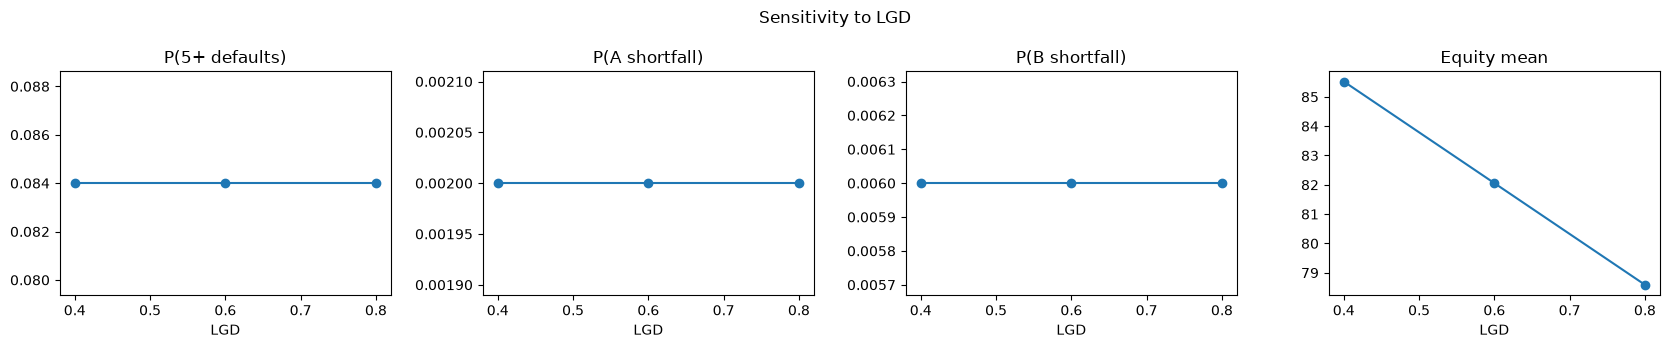

In [41]:
all_tables = run_all_sensitivities(Z_sorted)

titles = {"rho": "Sensitivity to correlation ρ",
          "pd_annual": "Sensitivity to annual PD",
          "LGD": "Sensitivity to LGD"}

for param, table in all_tables.items():
    print(f"\n{titles[param]}")
    display(table.round(4))
    plot_sensitivity(table, KEY_METRICS, title=titles[param],
                     save_path=PROJECT_ROOT / "Output" / f"sensitivity_{param}.png")

In [42]:
stress_table = run_stress(Z_sorted, pd_values=(0.02, 0.08), rho_values=(0.2, 0.5))
display(stress_table[["Avg defaults", "P(5+ defaults)", "P(A shortfall)",
                      "P(B shortfall)", "Equity mean", "Equity 5th pct"]].round(4))

Avg defaults  P(5+ defaults)  P(A shortfall)  P(B shortfall)  \
pd_annual rho                                                                 
0.02      0.2         0.958           0.011           0.001           0.001   
          0.5         0.955           0.058           0.010           0.013   
0.08      0.2         3.403           0.291           0.013           0.046   
          0.5         3.374           0.322           0.074           0.122   

               Equity mean  Equity 5th pct  
pd_annual rho                               
0.02      0.2      88.6516          69.715  
          0.5      88.9460          58.345  
0.08      0.2      70.4349          41.490  
          0.5      72.2816          40.950

**Sensitivity conclusions**

- **Correlation ρ makes bad scenarios worse, without changing the average.** From ρ = 0 to 0.5, average defaults stay at about 1.8, but the chance of 5+ defaults rises from 1.9% to 14.1%. Class A and B go from never short-paid to short-paid in 2.1% and 4.2% of cases. The equity's average barely moves, but its worst cases get worse.

- **PD raises losses across the board.** Doubling PD from 4% to 8% almost doubles defaults (1.8 → 3.4) and cuts the equity's average by about 12MM. Class B's shortfall probability rises from 0.6% to 4.6%.

- **LGD only affects the equity.** Higher LGD lowers the equity's average (85.5MM → 78.6MM) but leaves Class A and B unchanged. Recoveries arrive early and go to the equity, while the tranches depend on how many bonds survive to Q20.

- **A recession is the main danger for the tranches.** When PD (8%) and ρ (0.5) rise together, Class A is short-paid in 7.4% of cases and Class B in 12.2%, far more than either change alone.

**Takeaway:** Class A and B look almost riskless in the base case, but their risk rises sharply when defaults become both more frequent and more correlated. The equity, kept by the bank, carries most of the expected loss and is most sensitive to PD and LGD.